In [1]:
# Instalação de dependências necessárias
%pip install -q numpy matplotlib torch seaborn

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import seaborn as sns

# Configuração visual e reprodutibilidade
sns.set_theme(style='whitegrid')
torch.manual_seed(42)
np.random.seed(42)

Note: you may need to restart the kernel to use updated packages.


# 1. Contextualização histórica e motivação

Esta seção contextualiza historicamente o desenvolvimento dos otimizadores de redes neurais, explicando por que algoritmos clássicos evoluíram para as soluções de ponta utilizadas no aprendizado profundo moderno.

A otimização de funções de perda é o motor que permite o aprendizado de máquina. O método clássico de Gradiente Descendente (GD), baseado no cálculo de derivadas para encontrar pontos de mínimo, calcula o gradiente utilizando todo o conjunto de dados (Batch Gradient Descent). No entanto, carregar bases de dados massivas na memória tornou-se rapidamente inviável, motivando o desenvolvimento do Stochastic Gradient Descent (SGD), que utiliza apenas uma amostra (ou um mini-batch) por iteração, adicionando estocasticidade ao processo e acelerando as atualizações.

Apesar do sucesso do SGD (especialmente com o algoritmo de Backpropagation popularizado em 1986 por Geoffrey Hinton), redes neurais profundas enfrentam superfícies de erro complexas, repletas de mínimos locais e regiões de gradiente quase nulo (plateaus e ravinas). A solução anterior do SGD puro era insuficiente porque ficava facilmente estagnada nessas regiões e sofria com oscilações drásticas dependendo da escala das características. Para resolver isso, técnicas avançadas foram introduzidas: o Momentum adicionou inércia ao movimento do gradiente, o RMSprop (proposto por Hinton em 2012) introduziu taxas de aprendizado adaptativas dividindo o gradiente pela raiz da média móvel de gradientes passados ao quadrado, e o Adam (Kingma & Ba, 2014) combinou o melhor de ambos os mundos.

Em 2024-2025, o estado da arte para treinamento de grandes modelos é o AdamW (Loshchilov & Hutter, 2017), uma evolução que corrige a forma como o weight decay (regularização L2) é aplicado, desacoplando-o do cálculo do momento do gradiente para uma generalização superior.

# 2. Intuição e visualização

Esta seção constrói a intuição geométrica da superfície de erro e do gradiente, o que é fundamental para visualizar como os pesos de um modelo são iterativamente ajustados em direção ao erro mínimo.

Uma função de perda (ou custo) mede a diferença entre a predição do modelo e o valor real. O gradiente dessa função atua como uma bussola matematica que aponta sempre para a direção de maior crescimento da função. Como o objetivo é minimizar o erro, o otimizador dá um passo na direção oposta ao gradiente. A magnitude desse passo é controlada pela taxa de aprendizado (learning rate, $\eta$). Uma taxa muito baixa exige muitas iterações; uma taxa ideal alcança o mínimo rapidamente; uma taxa excessiva causa oscilações severas ou até divergência.

A célula de código abaixo ilustra uma superfície de custo 1D simples, $f(w) = w^2$, e simula como diferentes taxas de aprendizado afetam a trajetória da otimização geométrica.

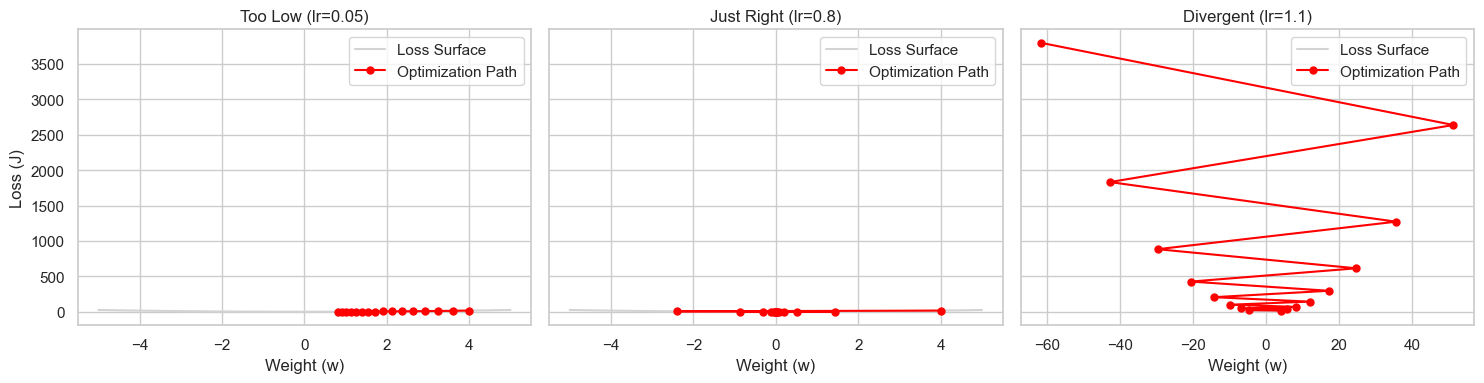

In [2]:
def loss_function(w):
    """Função de perda convexa simples: f(w) = w^2"""
    return w ** 2

def gradient_function(w):
    """Derivada da função de perda: f'(w) = 2w"""
    return 2 * w

def simulate_optimization(w_start, lr, epochs):
    """Simula a trajetória do gradiente descendente."""
    weights = [w_start]
    w = w_start
    for _ in range(epochs):
        grad = gradient_function(w)
        w = w - lr * grad
        weights.append(w)
    return weights

# Parâmetros de simulação
w_initial = 4.0
epochs_sim = 15
lrs = {'Too Low (lr=0.05)': 0.05, 'Just Right (lr=0.8)': 0.8, 'Divergent (lr=1.1)': 1.1}

# Visualização
w_space = np.linspace(-5, 5, 100)
loss_space = loss_function(w_space)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (title, lr) in zip(axes, lrs.items()):
    trajectory = simulate_optimization(w_initial, lr, epochs_sim)

    ax.plot(w_space, loss_space, color='lightgray', label='Loss Surface')
    ax.plot(trajectory, loss_function(np.array(trajectory)), marker='o', color='red',
            linestyle='-', markersize=5, label='Optimization Path')
    ax.set_title(title)
    ax.set_xlabel('Weight (w)')
    if ax is axes[0]:
        ax.set_ylabel('Loss (J)')
    ax.legend()

plt.tight_layout()
plt.show()

# 3. Teoria formal

Esta seção formaliza matematicamente os algoritmos de otimização, vital para garantir o rigor técnico necessário na implementação de arquiteturas complexas.

O Gradiente Descendente padrão atualiza os parâmetros $\theta$ do modelo na iteração $t$ baseando-se no gradiente da função de perda $J$:

$$ \theta^{(t+1)} = \theta^{(t)} - \eta \nabla J(\theta^{(t)}) $$

Interpretação: O novo peso é igual ao peso atual menos uma fração $\eta$ do erro instantâneo apontado pelo gradiente. A limitação deste método é a incapacidade de reter informações passadas sobre as trajetórias ou escapar de mínimos locais.

O Momentum atenua as oscilações e ganha inércia em direções consistentes, mantendo uma média móvel dos gradientes passados por meio do fator $\gamma$ (geralmente $0.9$):

$$ v^{(t+1)} = \gamma v^{(t)} + \eta \nabla J(\theta^{(t)}) $$
$$ \theta^{(t+1)} = \theta^{(t)} - v^{(t+1)} $$

Interpretação: O termo de velocidade $v$ acumula gradientes anteriores, permitindo que a otimização avance suavemente por regiões de baixa curvatura (ravinas).

O Adam (Adaptive Moment Estimation) propõe uma taxa de aprendizado adaptativa calculando dois momentos e aplicando uma correção de viés:

1. Primeiro Momento (Média dos gradientes): $m^{(t+1)} = \beta_1 m^{(t)} + (1 - \beta_1)\nabla J(\theta^{(t)})$
2. Segundo Momento (Média dos quadrados dos gradientes): $v^{(t+1)} = \beta_2 v^{(t)} + (1 - \beta_2)(\nabla J(\theta^{(t)}))^2$
3. Correção de Viés (Bias Correction): $\hat{m}^{(t+1)} = \frac{m^{(t+1)}}{1 - \beta_1^{t+1}}$, $\hat{v}^{(t+1)} = \frac{v^{(t+1)}}{1 - \beta_2^{t+1}}$
4. Atualização: $\theta^{(t+1)} = \theta^{(t)} - \frac{\eta}{\sqrt{\hat{v}^{(t+1)}} + \epsilon} \hat{m}^{(t+1)}$

Limitação do Adam: A regularização L2 (restrição imposta aos pesos para evitar overfitting) interage negativamente com a estimativa de média adaptativa no Adam padrão, misturando o termo de regularização dentro dos cálculos de média.

O AdamW resolve a limitação do Adam desacoplando o weight decay ($\lambda$) da fase de estimativa de gradiente, aplicando-o diretamente na atualização do peso:

$$ \theta^{(t+1)} = \theta^{(t)} - \eta \left( \frac{\hat{m}^{(t+1)}}{\sqrt{\hat{v}^{(t+1)}} + \epsilon} + \lambda \theta^{(t)} \right) $$

# 4. Algoritmos

Esta seção traduz o modelo matemático formulado na etapa anterior em um pseudocódigo algorítmico passo a passo, facilitando o design do software subjacente.

O pseudocódigo a seguir esquematiza a lógica de execução do otimizador AdamW durante o treinamento.

```text
Entradas:
    - theta_0: pesos iniciais
    - lr: taxa de aprendizado
    - beta1, beta2: coeficientes de decaimento para os momentos (tipicamente 0.9 e 0.999)
    - weight_decay: taxa de penalização dos pesos (L2)
    - eps: valor minúsculo para evitar divisão por zero (e.g., 1e-8)

Inicialização:
    - m_0 <- 0 (Vetor do primeiro momento)
    - v_0 <- 0 (Vetor do segundo momento)
    - t <- 0 (Contador de iterações)

Enquanto os parâmetros não convergirem:
    1. t <- t + 1
    2. grad <- CalcularGradiente(theta_{t-1})
    3. m_t <- beta1 * m_{t-1} + (1 - beta1) * grad
    4. v_t <- beta2 * v_{t-1} + (1 - beta2) * (grad * grad)
    5. m_hat <- m_t / (1 - beta1^t)
    6. v_hat <- v_t / (1 - beta2^t)
    7. passo_otimizado <- m_hat / (raiz_quadrada(v_hat) + eps)
    8. decaimento <- weight_decay * theta_{t-1}
    9. theta_t <- theta_{t-1} - lr * (passo_otimizado + decaimento)
Retorna theta
```

# 5. Implementação from scratch

Esta seção desenvolve o conceito central por meio de uma codificação pura utilizando apenas Python e NumPy, essencial para desmistificar o interior das bibliotecas fechadas (caixa-preta).

A implementação manual abaixo constrói a classe abstrata de um otimizador base e estende o raciocínio para programar o otimizador AdamW a partir do zero.

In [3]:
class OptimizerFromScratch:
    """Classe base para otimizadores."""
    def __init__(self, params, lr):
        self.params = [np.array(p, dtype=np.float32) for p in params]
        self.lr = lr

class AdamWFromScratch(OptimizerFromScratch):
    """
    Otimizador AdamW implementado do zero utilizando apenas NumPy.
    Desacopla o weight decay conforme detalhado pela literatura matemática.
    """
    def __init__(self, params, lr=0.001, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01):
        super().__init__(params, lr)
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.weight_decay = weight_decay

        # Inicializa momentos (m e v) com zeros, mesmo shape dos parâmetros
        self.m = [np.zeros_like(p) for p in self.params]
        self.v = [np.zeros_like(p) for p in self.params]
        self.t = 0

    def step(self, grads):
        """
        Executa um passo de otimização aplicando a regra do AdamW.
        Args:
            grads: Lista de gradientes (mesmo shape de params).
        """
        self.t += 1
        updated_params = []

        for i, (param, grad) in enumerate(zip(self.params, grads)):
            # 1. Atualização dos momentos (m e v)
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * grad
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (grad ** 2)

            # 2. Correção de viés (Bias correction)
            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            # 3. Desacoplamento do Weight Decay
            decay = self.weight_decay * param

            # 4. Atualização dos parâmetros
            step_update = m_hat / (np.sqrt(v_hat) + self.eps)
            param = param - self.lr * (step_update + decay)

            self.params[i] = param
            updated_params.append(param)

        return updated_params

# Célula de teste/assertabilidade local
w_test = [np.array(5.0, dtype=np.float32)]
grad_test = [np.array(10.0, dtype=np.float32)]
adamw_manual = AdamWFromScratch(w_test, lr=0.1, weight_decay=0.1)

# Simula 1 passo
new_w = adamw_manual.step(grad_test)
new_w_scalar = float(new_w[0])
print(f'Peso atualizado (Implementação Manual): {new_w_scalar:.5f}')

Peso atualizado (Implementação Manual): 4.85000


# 6. Implementação em PyTorch

Esta seção recria o algoritmo nativo implementado anteriormente através da API oficial do framework PyTorch, comprovando a equivalência absoluta das operações e permitindo escalabilidade para processamento via tensores em GPU.

A API nativa torch.optim.AdamW aceita a lista de tensores rastreáveis. O processo em PyTorch ocorre em três frentes: zero_grad() para limpar as iterações anteriores, backward() para o motor autograd inferir as derivadas e finalmente step() para a alteração dos pesos. A célula abaixo roda o exato mesmo cenário da implementação matricial from scratch e valida matematicamente a igualdade do cálculo final.

In [4]:
# Inicializa o tensor no PyTorch (equivalente a w_test = 5.0)
w_torch = torch.tensor([5.0], requires_grad=True)

# Instancia o otimizador AdamW do PyTorch
optimizer_torch = torch.optim.AdamW([w_torch], lr=0.1, weight_decay=0.1, betas=(0.9, 0.999), eps=1e-8)

# Simula a atribuição forçada do gradiente (grad_test = 10.0)
optimizer_torch.zero_grad()
w_torch.grad = torch.tensor([10.0])

# Executa o passo
optimizer_torch.step()

new_w_torch = w_torch.item()
print(f'Peso atualizado (Implementação PyTorch): {new_w_torch:.5f}')

# Validação estrita da equivalência algébrica
assert np.isclose(new_w_scalar, new_w_torch, atol=1e-5), 'As implementações diferem! Corrija a formulação do peso.'
print('ASSERT SUCESSO: A implementação do zero é matematicamente equivalente à API do PyTorch!')

Peso atualizado (Implementação PyTorch): 4.85000
ASSERT SUCESSO: A implementação do zero é matematicamente equivalente à API do PyTorch!


# 7. Experimentos e análise

Esta seção expõe a superfície do otimizador a experimentos controlados, sendo indispensável para diagnosticar patologias durante a modelagem de longo prazo, como as divergências geradas por parâmetros sub-ótimos.

Experimentos com o otimizador provam por que apenas possuir um gradiente exato não é suficiente; hiperparâmetros dominam a eficácia da redução do erro de validação. Observe que algoritmos avançados mitigam, mas não isentam a necessidade do ajuste preciso da taxa de aprendizado (learning rate) e estocasticidade de batches adequados. O código demonstra a trajetória da convergência em um espaço 2D desafiador, simulando as vales (ravines) frequentemente referidos nos conjuntos de dados complexos, exibindo o comportamento iterativo de SGD versus AdamW.

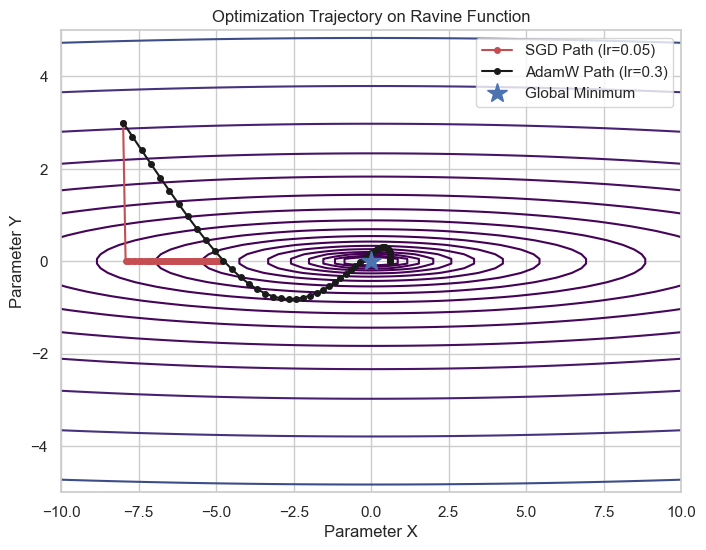

In [5]:
def function_2d_ravine(x, y):
    """
    Função de vale estreito (Ravine-like): f(x,y) = x^2 / 10 + 10 * y^2
    Testa a estabilidade direcional e inércia dos otimizadores.
    """
    return (x ** 2) / 10 + 10 * (y ** 2)

def gradient_2d_ravine(w):
    x, y = w[0], w[1]
    return np.array([x / 5.0, 20.0 * y], dtype=np.float32)

# Configuração de trajetórias
iters = 50
start_point = np.array([-8.0, 3.0], dtype=np.float32)

# Experimento SGD Simples
w_sgd = start_point.copy()
path_sgd = [w_sgd.copy()]
lr_sgd = 0.05
for _ in range(iters):
    grad = gradient_2d_ravine(w_sgd)
    w_sgd = w_sgd - lr_sgd * grad
    path_sgd.append(w_sgd.copy())

# Experimento AdamW (implementação manual da Seção 5)
w_adam = [np.array(start_point[0], dtype=np.float32), np.array(start_point[1], dtype=np.float32)]
adamw = AdamWFromScratch(w_adam, lr=0.3, weight_decay=0.0)
path_adam = [np.array([float(w_adam[0]), float(w_adam[1])], dtype=np.float32)]
for _ in range(iters):
    grad_vec = gradient_2d_ravine(np.array([float(w_adam[0]), float(w_adam[1])], dtype=np.float32))
    grads = [np.array(grad_vec[0], dtype=np.float32), np.array(grad_vec[1], dtype=np.float32)]
    w_adam = adamw.step(grads)
    path_adam.append(np.array([float(w_adam[0]), float(w_adam[1])], dtype=np.float32))

# Geração de gráficos e isolinhas
X, Y = np.meshgrid(np.linspace(-10, 10, 100), np.linspace(-5, 5, 100))
Z = function_2d_ravine(X, Y)

path_sgd = np.array(path_sgd)
path_adam = np.array(path_adam)

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap='viridis')
plt.plot(path_sgd[:, 0], path_sgd[:, 1], 'ro-', label='SGD Path (lr=0.05)', markersize=4, linewidth=1.5)
plt.plot(path_adam[:, 0], path_adam[:, 1], 'ko-', label='AdamW Path (lr=0.3)', markersize=4, linewidth=1.5)
plt.plot(0, 0, 'b*', markersize=15, label='Global Minimum')

plt.title('Optimization Trajectory on Ravine Function')
plt.xlabel('Parameter X')
plt.ylabel('Parameter Y')
plt.legend()
plt.show()

# 8. Conexões com ML moderno

Esta seção faz a ponte entre otimizadores clássicos formulados entre 1950 e 2017 com as estruturas bilionárias de IA contemporâneas, esclarecendo a obrigatoriedade absoluta do controle da escala matemática na era da Inteligência Artificial Generativa.

A escalabilidade dos modelos no período de 2024-2025, de imensos Transformadores para Processamento de Linguagem Natural (LLMs) a modelos de difusão de imagens, depende intrinsecamente do AdamW como padrão absoluto de mercado. O SGD tradicional tem convergência insustentável nessas hiperdimensões topológicas não-convexas. Contudo, o Adam/AdamW exige o armazenamento dos dois momentos iterativos por peso, triplicando os custos de alocação (o que em redes com parâmetros de bilhões exige terabytes inacessíveis de memória em GPU).

Como resposta, a engenharia de hardware e o ecossistema moderno aderem ao Mixed Precision Training (Treinamento em Precisão Mista). Através do remapeamento de matrizes completas (FP32) para precisões estreitas de 16-bits (FP16/BF16) ou 8-bits (FP8), os vetores dos momentos consomem de 2 a 4 vezes menos memória VRAM, mantendo a métrica inalterada. Isso corrobora os achados da literatura oficial de otimização, como demonstrado em Adam: A Method for Stochastic Optimization (Kingma & Ba).

Por que isso ainda importa em 2025? Porque os custos operacionais (FLOPS e consumo elétrico) de uma rede complexa continuam atrelados diretamente à eficiência do otimizador e às suas heurísticas de correção, fazendo da manipulação de precisão matemática a espinha dorsal de qualquer startup tecnológica atual.

# 9. Exercícios

Esta seção consolida o modelo mental do leitor sobre descida estocástica propondo testes reflexivos e algoritmos sem resposta pronta.

#### Exercícios Resolvidos

**1. Correção de viés no início do treinamento:**
Por que o AdamW precisa da correção de viés $\hat{m}$ e $\hat{v}$ (bias correction) especificamente nas primeiras épocas do treinamento?

*Solução:* Inicialmente, os vetores $m$ e $v$ recebem arrays compostos de zeros. Sem a correção, nas iterações iniciais $t \approx 1$, a média exponencial é brutalmente puxada para zero pelos fatores iniciais. A divisão por $(1 - \beta^t)$ atua como escalonador corretivo, aproximando temporariamente o quociente do gradiente real no início.

**2. A importância da randomização no Dataloader:**
Qual a justificativa fundamental para utilizar shuffle=True (embaralhamento) ao treinar via Stochastic Gradient Descent ou Mini-batch?

*Solução:* Sem a aleatorização dos batches, uma rede assimila a ordem estrutural dos padrões como decoreba posicional em vez das feições contextuais. No final da época o gradiente seria repetitivo. Redes rasas sobreajustariam rapidamente o ciclo estático (data leakage temporal induzido).

**3. O impacto do batch nos ruídos direcionais:**
Dado a fórmula do GD contra o Mini-batch Gradient Descent, explique por que o SGD puro é altamente propenso ao ruído em comparação com os Mini-batches.

*Solução:* A atualização baseada numa única amostra perpassa as anomalias diretas (outliers) daquele único caso à retropropagação dos parâmetros. O Mini-batch suaviza as aberrações e promedia a inclinação em uma amostra significativa, balanceando estabilidade matemática estocástica e velocidade superior.

#### Desafios Abertos

**Desafio 1 (Implementação RMSprop vs Adam):**
Implemente a otimização RMSprop localmente e oponha-a visualmente com seu próprio Adam. Modifique o peso inicial para observar empiricamente por que a inserção da média móvel simples do gradiente (Momentum) acoplado pelo Adam produz curvas muito mais contínuas em landscapes rugosas.
*Dica:* Consulte a teoria da Seção 3 e foque na exclusão do $m^{(t+1)}$ nativo do Adam. A atualização dependerá exclusivamente do $v^{(t+1)}$ suavizador.

**Desafio 2 (Learning Rate Scheduler dinâmico):**
Redes em produção (ex: Visão Computacional ou NLP) evitam taxas de aprendizado imóveis. Crie e plote matematicamente um mecanismo CosineAnnealingLR (Cosseno Cíclico) e conecte-o no loop principal de treinamento do PyTorch desenvolvido na Seção 6.
*Dica:* O Learning Rate Scheduler oscila a variável optimizer.param_groups['lr'] entre picos máximos definidos pelo engenheiro (0.1) e bases limitadoras suaves antes do reinício do período de treinamento, para escapar gradativamente de mínimos locais problemáticos. Utilize o pacote nativo ou programe matematicamente.